# Exploratory Data Analysis on a Used Cars Dataset
**Student Name:** _N Shasank Kumar Reddy_  |  **Date:** _28th September, 2026_

**Dataset source:** `used_cars_dataset_v2.csv` – used-car listings (India, Dec 2023 – Dec 2024) taken from Kaggle

**References:** Pandas, NumPy, Matplotlib and Seaborn official documentation; Help of Claude was taken for Grammar part, to clear doubts, errors in the code and for refinement. Final review was done by Claude before submission.

---
## 1. Objective
Clean the dataset, explore it and communicate patterns. Questions selected:
1. Which brands, fuel types and transmissions are most common?
2. How are asking prices distributed?
3. How do vehicle age and mileage relate to price?
4. Do automatic and manual cars differ in price?
5. Which brands have the highest average price?
6. Which features are correlated, and where are the outliers?

In [22]:
# ---- Imports & settings ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 2. Dataset Overview

In [23]:
# Load the data (keep the CSV in the same folder as this notebook)
df_raw = pd.read_csv("used_cars_dataset_v2.csv")

print("Shape (rows, columns):", df_raw.shape)
print("\nColumns and data types:")
print(df_raw.dtypes)
df_raw.head()

Shape (rows, columns): (14993, 11)

Columns and data types:
Brand           object
model           object
Year             int64
Age              int64
kmDriven        object
Transmission    object
Owner           object
FuelType        object
PostedDate      object
AdditionInfo    object
AskPrice        object
dtype: object


,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,Honda,City,2001,23,"98,000 km",Manual,second,Petrol,Nov-24,"Honda City v teck in mint condition, valid gen...","₹ 1,95,000"
1,Toyota,Innova,2009,15,190000.0 km,Manual,second,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...","₹ 3,75,000"
2,Volkswagen,VentoTest,2010,14,"77,246 km",Manual,first,Diesel,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...","₹ 1,84,999"
3,Maruti Suzuki,Swift,2017,7,"83,500 km",Manual,second,Diesel,Nov-24,Maruti Suzuki Swift 2017 Diesel Good Condition,"₹ 5,65,000"
4,Maruti Suzuki,Baleno,2019,5,"45,000 km",Automatic,first,Petrol,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol","₹ 6,85,000"


**Feature description**

| Column | Meaning |
|---|---|
| Brand, model | Manufacturer and car model |
| Year, Age | Manufacturing year and age of car (Age = 2024 − Year) |
| kmDriven | Kilometres driven (text such as "98,000 km") |
| Transmission | Manual / Automatic |
| Owner | first / second owner |
| FuelType | Petrol / Diesel / Hybrid-CNG (inconsistently labelled) |
| PostedDate | Month the ad was posted |
| AdditionInfo | Free-text listing description |
| AskPrice | Asking price in ₹ (text such as "₹ 1,95,000") |

Note: `AskPrice` is the **seller's asking price**, not the final sale price.

In [24]:
# Separate numerical and categorical variables
print("Numerical (as loaded):", df_raw.select_dtypes(include="number").columns.tolist())
print("Categorical (as loaded):", df_raw.select_dtypes(exclude="number").columns.tolist())
print("\nNote: kmDriven and AskPrice are numbers stored as text -> need conversion.")

Numerical (as loaded): ['Year', 'Age']
Categorical (as loaded): ['Brand', 'model', 'kmDriven', 'Transmission', 'Owner', 'FuelType', 'PostedDate', 'AdditionInfo', 'AskPrice']

Note: kmDriven and AskPrice are numbers stored as text -> need conversion.


## 3. Data Quality Checks (before cleaning)

In [25]:
rows_before = len(df_raw)
print("Missing values per column:")
print(df_raw.isna().sum())
print("\nDuplicate rows:", df_raw.duplicated().sum())

print("\nInconsistent categories:")
print("FuelType :", df_raw["FuelType"].value_counts().to_dict())
print("Owner    :", df_raw["Owner"].value_counts().to_dict())
print("Brand values that look odd:", [b for b in df_raw["Brand"].unique() if b in ("Toyota Land", "ICML", "Ashok")])
print("\nYear range:", df_raw["Year"].min(), "to", df_raw["Year"].max(), "| Age max:", df_raw["Age"].max())

Missing values per column:
Brand            0
model            0
Year             0
Age              0
kmDriven        88
Transmission     0
Owner            0
FuelType         0
PostedDate       0
AdditionInfo     0
AskPrice         0
dtype: int64

Duplicate rows: 997

Inconsistent categories:
FuelType : {'Petrol': 5822, 'Diesel': 5239, 'hybrid': 2012, 'Hybrid/CNG': 1920}
Owner    : {'second': 7794, 'first': 7199}
Brand values that look odd: ['ICML', 'Ashok', 'Toyota Land']

Year range: 1900 to 2024 | Age max: 124


## 4. Data Cleaning (with decisions)
| # | Issue | Decision & reason |
|---|---|---|
| 1 | Duplicate rows | Removed – repeated listings would bias counts and averages. |
| 2 | `kmDriven` / `AskPrice` are text | Stripped "km", "₹" and commas, converted to numbers. |
| 3 | `FuelType`: "hybrid" and "Hybrid/CNG" | Merged into one label, "Hybrid/CNG" (same category, different spelling). |
| 4 | `Brand`: "Toyota Land" | Fixed to "Toyota" (Land Cruiser model split into the brand column). |
| 5 | `Owner`, `model` text | Standardised capitalisation and removed hyphens/underscores in model names. |
| 6 | Impossible years (before 1950, e.g. a 1900 Renault Triber) | Removed – clear data-entry errors (Age up to 124). |
| 7 | Prices below ₹25,000 (e.g. a 2014 BMW 5 Series at ₹15,000) | Removed – unrealistic, likely typos or placeholder prices. |
| 8 | `kmDriven` = 0 for used cars | Treated as missing (a used car with 0 km is not credible). |
| 9 | Missing `kmDriven` | Filled with the median km of cars of the same age (median is robust to outliers). |
| 10 | Very expensive cars (Rolls-Royce, Lamborghini…) | **Kept** – they are genuine luxury listings, not errors. Handled with a log scale in charts. |

In [26]:
df = df_raw.copy()

# 1. Duplicates
df = df.drop_duplicates()

# 2. Convert text columns to numbers
df["km"] = pd.to_numeric(df["kmDriven"].str.replace("km", "").str.replace(",", "").str.strip(), errors="coerce")
df["price"] = df["AskPrice"].str.replace("₹", "").str.replace(",", "").str.strip().astype(float)

# 3-5. Fix inconsistent labels
df["FuelType"] = df["FuelType"].replace({"hybrid": "Hybrid/CNG"})
df["Brand"] = df["Brand"].replace({"Toyota Land": "Toyota"})
df["Owner"] = df["Owner"].str.title()
df["model"] = df["model"].str.replace("-", " ").str.replace("_", " ").str.strip().str.title()

# 6. Impossible years
df = df[df["Year"] >= 1950]

# 7. Unrealistic prices
df = df[df["price"] >= 25000]

# 8-9. Mileage: 0 km -> missing, then impute with median km of same age
df.loc[df["km"] == 0, "km"] = np.nan
df["km"] = df["km"].fillna(df.groupby("Age")["km"].transform("median"))
df["km"] = df["km"].fillna(df["km"].median())   # safety net for ages with no data

# Helper columns for analysis
df["log_price"] = np.log10(df["price"])
df["price_lakh"] = df["price"] / 1e5
df["km_thousand"] = df["km"] / 1000
df = df.drop(columns=["kmDriven", "AskPrice"]).reset_index(drop=True)

rows_after = len(df)
print(f"Rows before cleaning : {rows_before}")
print(f"Rows after cleaning  : {rows_after}")
print(f"Rows removed         : {rows_before - rows_after} ({(rows_before - rows_after) / rows_before:.1%})")
print("Remaining missing values:", int(df[['km', 'price']].isna().sum().sum()))
df.head()

Rows before cleaning : 14993
Rows after cleaning  : 13984
Rows removed         : 1009 (6.7%)
Remaining missing values: 0


,Brand,model,Year,Age,Transmission,Owner,FuelType,PostedDate,AdditionInfo,km,price,log_price,price_lakh,km_thousand
0,Honda,City,2001,23,Manual,Second,Petrol,Nov-24,"Honda City v teck in mint condition, valid gen...","98,000.00","195,000.00",5.29,1.95,98.00
1,Toyota,Innova,2009,15,Manual,Second,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...","190,000.00","375,000.00",5.57,3.75,190.00
2,Volkswagen,Ventotest,2010,14,Manual,First,Diesel,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...","77,246.00","184,999.00",5.27,1.85,77.25
3,Maruti Suzuki,Swift,2017,7,Manual,Second,Diesel,Nov-24,Maruti Suzuki Swift 2017 Diesel Good Condition,"83,500.00","565,000.00",5.75,5.65,83.50
4,Maruti Suzuki,Baleno,2019,5,Automatic,First,Petrol,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol","45,000.00","685,000.00",5.84,6.85,45.00


## 5. Descriptive Statistics

In [27]:
num_cols = ["Year", "Age", "km", "price"]
print("Numerical columns:")
display(df[num_cols].describe().T)
print("Skewness of price:", round(df["price"].skew(), 2), "| Skewness of km:", round(df["km"].skew(), 2))

Numerical columns:


,count,mean,std,min,25%,50%,75%,max
Year,"13,984.00","2,016.35",4.14,"1,978.00","2,014.00","2,017.00","2,019.00","2,024.00"
Age,"13,984.00",7.65,4.14,0.00,5.00,7.00,10.00,46.00
km,"13,984.00","71,651.41","58,126.04",1.00,"44,694.50","66,000.00","87,000.00","980,002.00"
price,"13,984.00","980,671.23","1,586,229.47","27,000.00","340,000.00","560,000.00","990,000.00","42,500,000.00"


Skewness of price: 8.4 | Skewness of km: 6.9


In [28]:
print("Categorical columns:")
display(df[["Brand", "model", "Transmission", "Owner", "FuelType"]].describe().T)
for col in ["Transmission", "Owner", "FuelType"]:
    print(f"\n{col} share (%):")
    print((df[col].value_counts(normalize=True) * 100).round(1))

Categorical columns:


,count,unique,top,freq
Brand,13984,42,Maruti Suzuki,4392
model,13984,416,Wagon R,642
Transmission,13984,2,Manual,7082
Owner,13984,2,Second,7145
FuelType,13984,3,Petrol,5395



Transmission share (%):
Transmission
Manual      50.60
Automatic   49.40
Name: proportion, dtype: float64

Owner share (%):
Owner
Second   51.10
First    48.90
Name: proportion, dtype: float64

FuelType share (%):
FuelType
Petrol       38.60
Diesel       34.60
Hybrid/CNG   26.80
Name: proportion, dtype: float64


**Observation:** Mean price is far above the median and skewness is high, so the price distribution is heavily right-skewed (a few very expensive luxury cars). The **median** is therefore a fairer "typical price" than the mean, and a log scale is used in charts.

## 6. Visual EDA

### Chart 1 – Most common brands (bar/count plot)

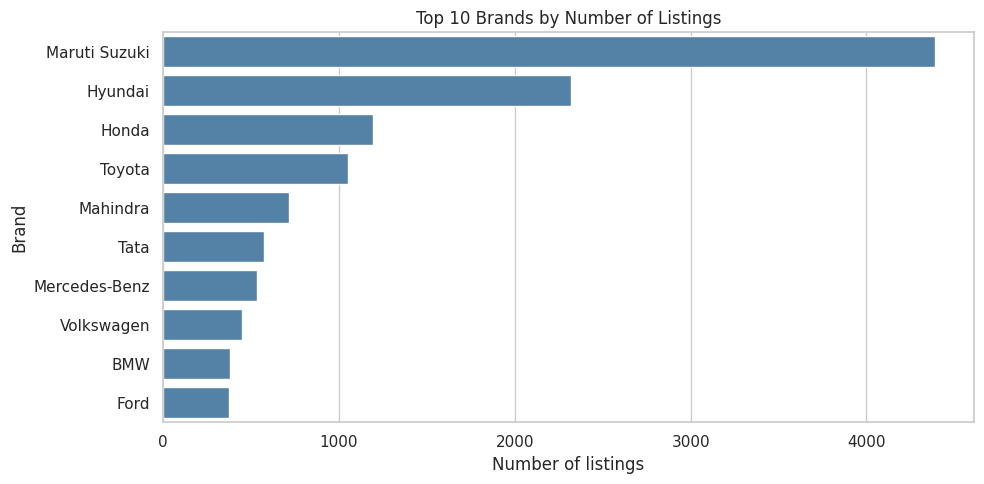

Maruti Suzuki share: 31.4%; Top 3 brands share: 56.5%


In [29]:
top_brands = df["Brand"].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_brands.values, y=top_brands.index, color="steelblue")
plt.title("Top 10 Brands by Number of Listings")
plt.xlabel("Number of listings")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()
print(f"Maruti Suzuki share: {top_brands.iloc[0] / len(df):.1%}; Top 3 brands share: {top_brands.head(3).sum() / len(df):.1%}")

**Observation:** Maruti Suzuki dominates the listings, followed by Hyundai and Honda. The top three brands account for well over half of the dataset, so brand-level conclusions for rare brands (e.g. Rolls-Royce, Lamborghini) rest on very few cars.

### Chart 2 – Fuel type and transmission mix (count plots)

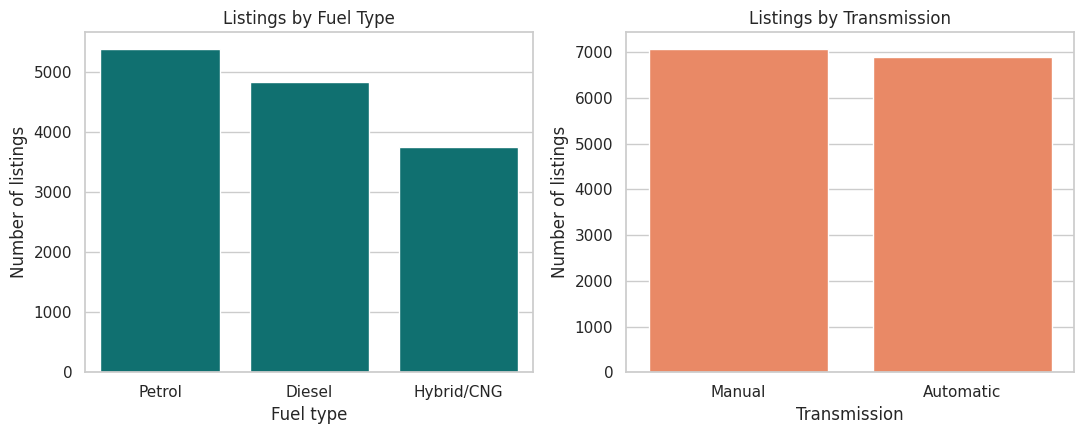

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
sns.countplot(data=df, x="FuelType", order=df["FuelType"].value_counts().index, ax=ax[0], color="teal")
ax[0].set_title("Listings by Fuel Type")
ax[0].set_xlabel("Fuel type"); ax[0].set_ylabel("Number of listings")
sns.countplot(data=df, x="Transmission", ax=ax[1], color="coral")
ax[1].set_title("Listings by Transmission")
ax[1].set_xlabel("Transmission"); ax[1].set_ylabel("Number of listings")
plt.tight_layout()
plt.show()

**Observation:** Petrol and Diesel are the most common fuel types, with Hybrid/CNG (after merging the two spellings) making up a smaller share. Manual and Automatic cars are almost equally represented, which makes price comparison between them fair in terms of sample size.

### Chart 3 – Distribution of asking price (histograms)

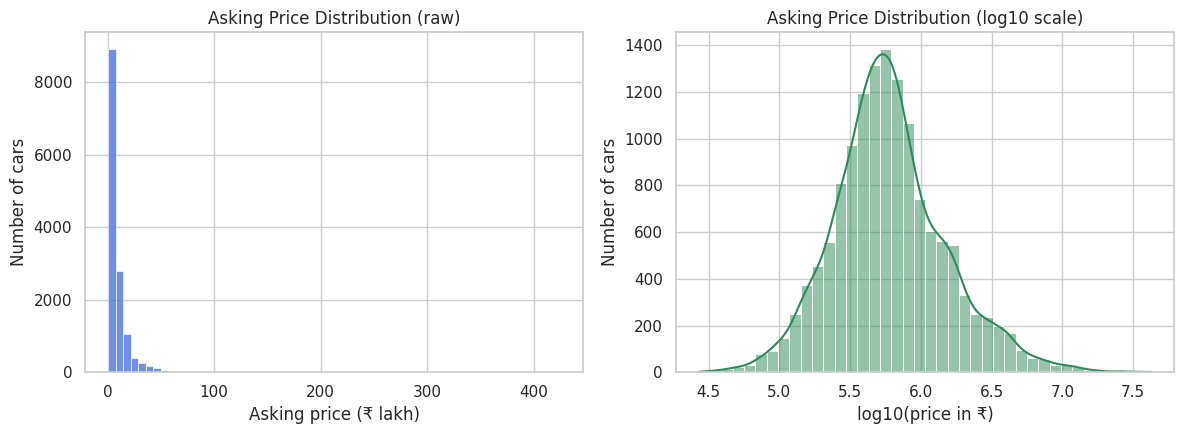

Median price: ₹560,000 | Mean price: ₹980,671


In [31]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df["price_lakh"], bins=60, ax=ax[0], color="royalblue")
ax[0].set_title("Asking Price Distribution (raw)")
ax[0].set_xlabel("Asking price (₹ lakh)"); ax[0].set_ylabel("Number of cars")
sns.histplot(df["log_price"], bins=40, kde=True, ax=ax[1], color="seagreen")
ax[1].set_title("Asking Price Distribution (log10 scale)")
ax[1].set_xlabel("log10(price in ₹)"); ax[1].set_ylabel("Number of cars")
plt.tight_layout()
plt.show()
print("Median price: ₹{:,.0f} | Mean price: ₹{:,.0f}".format(df["price"].median(), df["price"].mean()))

**Observation:** The raw price is strongly right-skewed – most cars are under ₹10 lakh with a long tail of luxury cars. After the log transformation the distribution is much more symmetric, which is better for comparing groups.

### Chart 4 – Automatic vs Manual price (box plot)

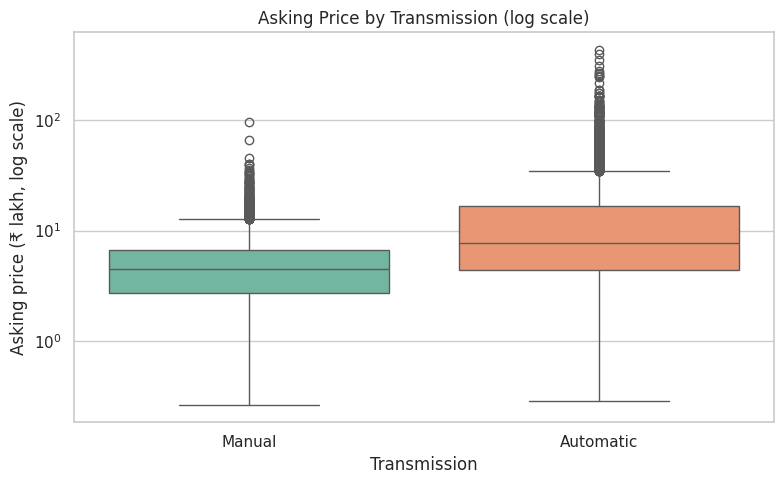

              count     median         mean
Transmission                               
Automatic      6902 775,000.00 1,440,192.00
Manual         7082 450,000.00   532,830.00


In [32]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Transmission", y="price_lakh", palette="Set2")
plt.yscale("log")
plt.title("Asking Price by Transmission (log scale)")
plt.xlabel("Transmission"); plt.ylabel("Asking price (₹ lakh, log scale)")
plt.tight_layout()
plt.show()
print(df.groupby("Transmission")["price"].agg(["count", "median", "mean"]).round(0))

**Observation:** Automatic cars have a clearly higher median price than manual cars (roughly 1.7x). Caution: this is partly because most luxury brands sell only automatics, so transmission is mixed up with brand/segment – it does not prove that the gearbox alone raises the price.

### Chart 5 – Age vs price (scatter plot)

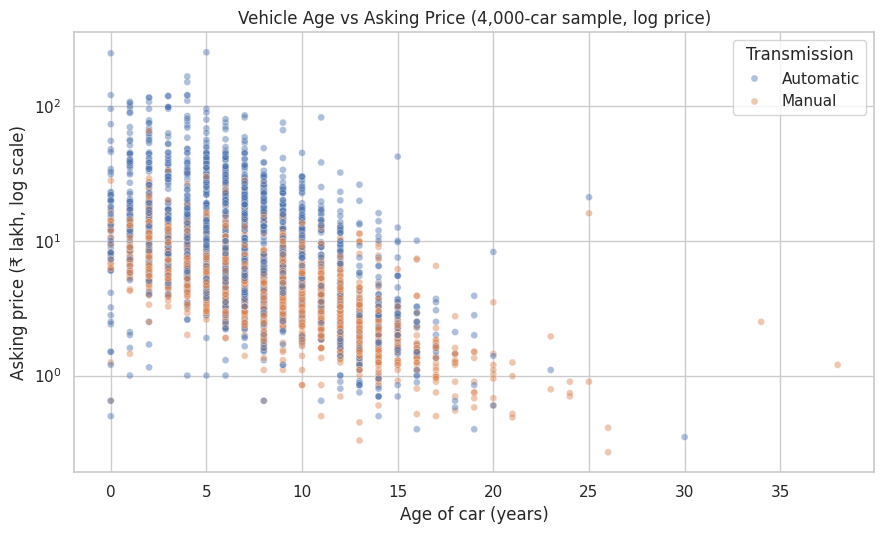

Age
0    1,192,500.00
3      970,000.00
5      700,000.00
10     449,000.00
15     195,000.00
Name: price, dtype: float64
Spearman correlation (Age, price): -0.6


In [33]:
plt.figure(figsize=(9, 5.5))
sample = df.sample(4000, random_state=42)
sns.scatterplot(data=sample, x="Age", y="price_lakh", hue="Transmission", alpha=0.45, s=25)
plt.yscale("log")
plt.title("Vehicle Age vs Asking Price (4,000-car sample, log price)")
plt.xlabel("Age of car (years)"); plt.ylabel("Asking price (₹ lakh, log scale)")
plt.tight_layout()
plt.show()
print(df.groupby("Age")["price"].median().loc[[0, 3, 5, 10, 15]].round(0))
print("Spearman correlation (Age, price):", round(df[["Age", "price"]].corr(method="spearman").iloc[0, 1], 2))

**Observation:** Price falls steadily as cars get older – median asking price drops from over ₹9 lakh for cars ≤3 years old to under ₹4.5 lakh at 10 years. The spread stays wide at every age because brand matters a lot. Automatic cars have a higher median price than manual ones at every age from 0 to 15 years.

### Chart 6 – Mileage vs price (scatter plot with trend line)

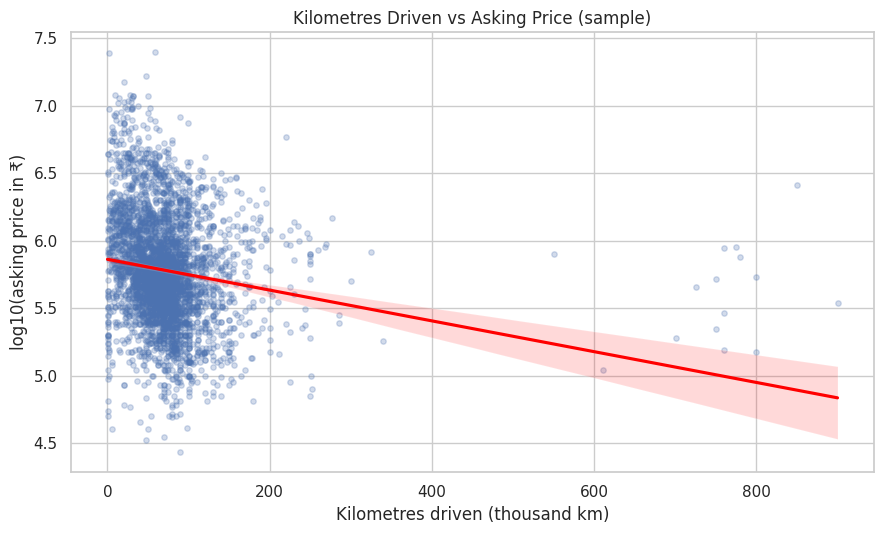

Spearman correlation (km, price): -0.25


In [34]:
plt.figure(figsize=(9, 5.5))
sns.regplot(data=sample, x="km_thousand", y="log_price", scatter_kws={"alpha": 0.25, "s": 15}, line_kws={"color": "red"})
plt.title("Kilometres Driven vs Asking Price (sample)")
plt.xlabel("Kilometres driven (thousand km)"); plt.ylabel("log10(asking price in ₹)")
plt.tight_layout()
plt.show()
print("Spearman correlation (km, price):", round(df[["km", "price"]].corr(method="spearman").iloc[0, 1], 2))

**Observation:** Higher mileage is associated with a lower price, but the relationship is weaker than for age (correlation is only mildly negative). Mileage and age are themselves related, so part of the mileage effect is really an age effect.

### Chart 7 – Brands with the highest median price (bar plot)

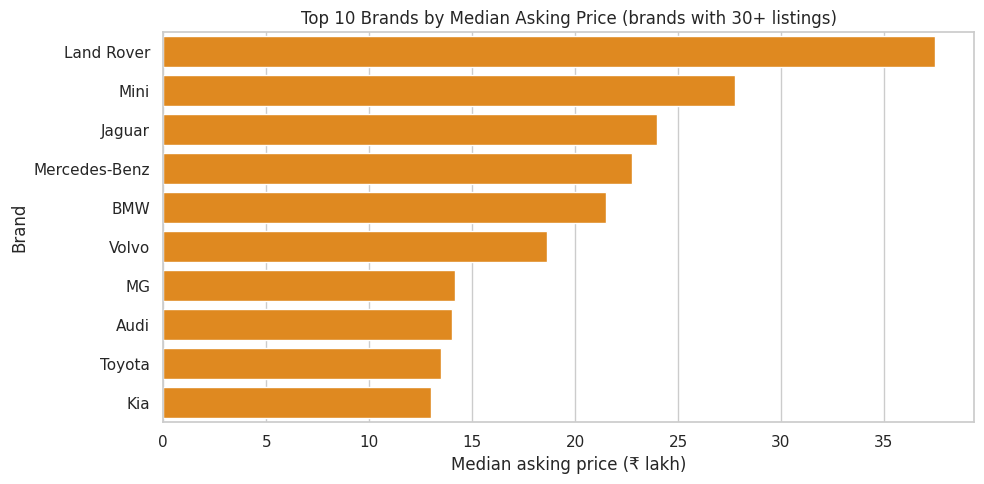

,count,median
Brand,,
Land Rover,97,"3,750,000.00"
Mini,40,"2,775,000.00"
Jaguar,47,"2,400,000.00"
Mercedes-Benz,536,"2,275,000.00"
BMW,377,"2,150,000.00"
Volvo,64,"1,865,000.00"
MG,108,"1,415,000.00"
Audi,282,"1,400,000.00"
Toyota,1052,"1,350,000.00"


In [35]:
brand_stats = df.groupby("Brand")["price"].agg(["count", "median"])
brand_stats = brand_stats[brand_stats["count"] >= 30].sort_values("median", ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=brand_stats["median"] / 1e5, y=brand_stats.index, color="darkorange")
plt.title("Top 10 Brands by Median Asking Price (brands with 30+ listings)")
plt.xlabel("Median asking price (₹ lakh)"); plt.ylabel("Brand")
plt.tight_layout()
plt.show()
display(brand_stats)

**Observation:** Luxury brands (Land Rover, Mini, Jaguar, Mercedes-Benz, BMW) lead in median price, while mass-market brands such as Maruti Suzuki, Renault and Chevrolet do not appear in the top 10 at all. Only brands with at least 30 listings are shown so that medians are reliable.

### Chart 8 – Price by fuel type and owner (box plots)

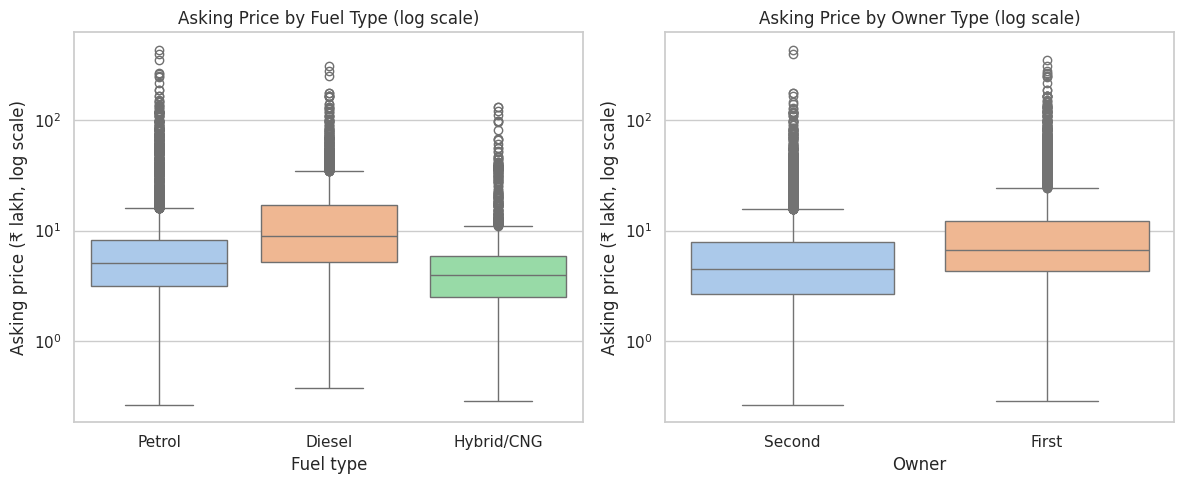

FuelType
Diesel       885,000.00
Hybrid/CNG   400,000.00
Petrol       509,000.00
Name: price, dtype: float64
Owner
First    675,000.00
Second   450,000.00
Name: price, dtype: float64


In [36]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x="FuelType", y="price_lakh", ax=ax[0], palette="pastel")
ax[0].set_yscale("log"); ax[0].set_title("Asking Price by Fuel Type (log scale)")
ax[0].set_xlabel("Fuel type"); ax[0].set_ylabel("Asking price (₹ lakh, log scale)")
sns.boxplot(data=df, x="Owner", y="price_lakh", ax=ax[1], palette="pastel")
ax[1].set_yscale("log"); ax[1].set_title("Asking Price by Owner Type (log scale)")
ax[1].set_xlabel("Owner"); ax[1].set_ylabel("Asking price (₹ lakh, log scale)")
plt.tight_layout()
plt.show()
print(df.groupby("FuelType")["price"].median().round(0))
print(df.groupby("Owner")["price"].median().round(0))

**Observation:** Diesel cars have the highest median price, well above Petrol and Hybrid/CNG. First-owner cars are listed at higher prices than second-owner cars. Both differences are also influenced by age and segment (e.g. diesel is common in SUVs).

### Chart 9 – Correlation heatmap (multivariate)

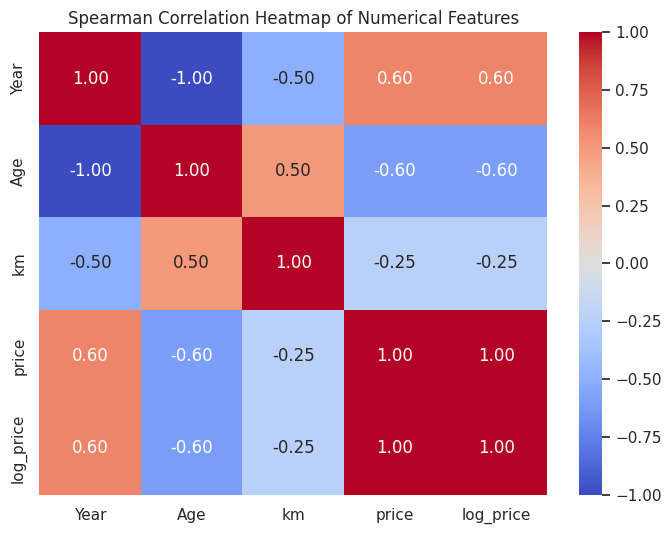

In [37]:
corr = df[["Year", "Age", "km", "price", "log_price"]].corr(method="spearman")
plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Spearman Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

**Observation:** Year and Age are perfectly (negatively) correlated because Age = 2024 − Year, so one of them is redundant. Price is moderately negatively correlated with Age (about -0.6) and weakly with km (about -0.25). Age and km are positively correlated (older cars have more km).

### Chart 10 – Median price by age group and fuel type (multivariate heatmap)

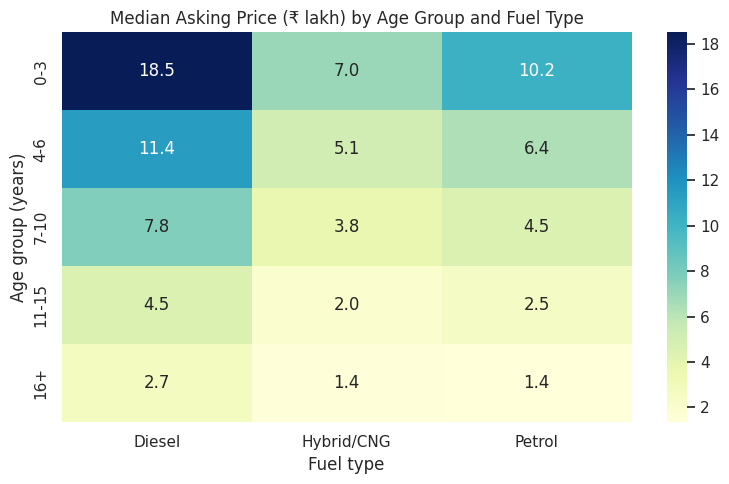

In [38]:
df["age_group"] = pd.cut(df["Age"], bins=[-1, 3, 6, 10, 15, 100], labels=["0-3", "4-6", "7-10", "11-15", "16+"])
pivot = df.pivot_table(index="age_group", columns="FuelType", values="price_lakh", aggfunc="median")
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Median Asking Price (₹ lakh) by Age Group and Fuel Type")
plt.xlabel("Fuel type"); plt.ylabel("Age group (years)")
plt.tight_layout()
plt.show()

**Observation:** In every fuel type, price falls as the age group increases. Diesel cars have the highest median price in every age group. This confirms that the age effect holds across fuel types.

## 7. Outlier Analysis

In [39]:
# IQR method on log price (raw price is too skewed for IQR to be meaningful)
q1, q3 = df["log_price"].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = df[(df["log_price"] < low) | (df["log_price"] > high)]
print(f"Price outliers (IQR on log price): {len(outliers)} rows ({len(outliers) / len(df):.1%})")
print(f"Price threshold for high outliers: ₹{10 ** high:,.0f}")
print("\nMost expensive listings:")
display(df.nlargest(5, "price")[["Brand", "model", "Year", "km", "price"]])
print("Highest mileage listings:")
display(df.nlargest(5, "km")[["Brand", "model", "Year", "km", "price"]])
print("High-price outliers by brand (top 5):")
print(outliers["Brand"].value_counts().head(5))

Price outliers (IQR on log price): 377 rows (2.7%)
Price threshold for high outliers: ₹4,918,918

Most expensive listings:


,Brand,model,Year,km,price
3148,Rolls-Royce,Phantom Series Ii,2015,"11,500.00","42,500,000.00"
11843,Lamborghini,Urus,2021,"26,000.00","39,000,000.00"
12400,Mercedes-Benz,G Class,2023,"6,000.00","34,800,000.00"
9555,Mercedes-Benz,G Class,2024,"3,500.00","30,500,000.00"
936,Lexus,Lx,2024,"24,000.00","27,750,000.00"


Highest mileage listings:


,Brand,model,Year,km,price
6269,Volkswagen,Polo,2019,"980,002.00","675,000.00"
4494,Maruti Suzuki,Alto 800,2019,"980,000.00","310,000.00"
7214,Chevrolet,Cruze,2012,"950,000.00","350,000.00"
12379,Hyundai,Accent,2011,"950,000.00","140,000.00"
13907,Honda,Amaze,2018,"950,000.00","320,000.00"


High-price outliers by brand (top 5):
Brand
Mercedes-Benz    102
BMW               54
Land Rover        39
Maruti Suzuki     37
Toyota            23
Name: count, dtype: int64


**Outlier decision:** About 79% of the flagged outliers are high-priced and mostly genuine luxury cars (Mercedes-Benz, BMW, Land Rover), while the rest are very cheap listings (e.g. old Maruti cars near the lower price limit). All were **kept**, because they look like real listings rather than errors. Only impossible values (years before 1950, prices below ₹25,000, 0 km) were treated as errors. Extremely high mileage (up to ~9.8 lakh km) is unusual but possible for taxis, so it was also kept.

## 8. Key Findings

In [40]:
med_auto = df[df.Transmission == "Automatic"]["price"].median()
med_man = df[df.Transmission == "Manual"]["price"].median()
top_brand = df["Brand"].value_counts()
top_price = brand_stats.index[0]
age_corr = df[["Age", "price"]].corr(method="spearman").iloc[0, 1]
km_corr = df[["km", "price"]].corr(method="spearman").iloc[0, 1]
fuel_med = df.groupby("FuelType")["price"].median()
own_med = df.groupby("Owner")["price"].median()

findings = [
    f"1. Market is concentrated: {top_brand.index[0]} alone makes up {top_brand.iloc[0] / len(df):.1%} of listings, and the top 3 brands {top_brand.head(3).sum() / len(df):.1%}.",
    f"2. Prices are highly right-skewed: median ₹{df.price.median():,.0f} vs mean ₹{df.price.mean():,.0f}, driven by a small number of luxury cars.",
    f"3. Age is the strongest numeric driver of price (Spearman {age_corr:.2f}); mileage is weaker ({km_corr:.2f}) and overlaps with age.",
    f"4. Automatic cars have a median price of ₹{med_auto:,.0f} vs ₹{med_man:,.0f} for manual ({med_auto / med_man:.1f}x), partly because luxury brands are mostly automatic.",
    f"5. Brand/segment matters a lot: {top_price} has the highest median price among brands with 30+ listings (₹{brand_stats['median'].iloc[0]:,.0f}).",
    f"6. Diesel cars have the highest median price (₹{fuel_med['Diesel']:,.0f}) vs Petrol (₹{fuel_med['Petrol']:,.0f}); first-owner cars (₹{own_med['First']:,.0f}) are listed higher than second-owner cars (₹{own_med['Second']:,.0f}).",
    "7. Data-quality issues (duplicates, inconsistent fuel labels, impossible years, unrealistic prices) affected about 7% of rows (1,009 of 14,993) and needed cleaning before analysis.",
]
for f in findings:
    print(f)

1. Market is concentrated: Maruti Suzuki alone makes up 31.4% of listings, and the top 3 brands 56.5%.
2. Prices are highly right-skewed: median ₹560,000 vs mean ₹980,671, driven by a small number of luxury cars.
3. Age is the strongest numeric driver of price (Spearman -0.60); mileage is weaker (-0.25) and overlaps with age.
4. Automatic cars have a median price of ₹775,000 vs ₹450,000 for manual (1.7x), partly because luxury brands are mostly automatic.
5. Brand/segment matters a lot: Land Rover has the highest median price among brands with 30+ listings (₹3,750,000).
6. Diesel cars have the highest median price (₹885,000) vs Petrol (₹509,000); first-owner cars (₹675,000) are listed higher than second-owner cars (₹450,000).
7. Data-quality issues (duplicates, inconsistent fuel labels, impossible years, unrealistic prices) affected about 7% of rows (1,009 of 14,993) and needed cleaning before analysis.


### Limitations
- `AskPrice` is what sellers *ask*, not the final selling price.
- The dataset has no engine size, horsepower or car condition, so those effects cannot be studied.
- The relationships shown are associations, **not causation** (e.g. transmission vs price is confounded by brand).
- Rare brands have very few listings, so their averages are unreliable.
- Missing mileage was imputed with the median for same-age cars, which slightly reduces natural variation.
- Listings cover only about one year (Dec 2023 – Dec 2024), so long-term price trends cannot be assessed.

## 9. Conclusion
The EDA cleaned a 14,993-row listings dataset (duplicates, text-to-number conversion, inconsistent labels, impossible values) and explored it with 10 charts across bar, count, histogram, box, scatter and heatmap types. The main learning: used-car prices are right-skewed, fall with age and mileage, and are dominated by brand segment, with automatic, diesel and first-owner cars listed higher on average. The main challenges were messy text columns and deciding which outliers were errors versus genuine luxury cars.

**Possible future analysis:** build a regression model to predict price, extract engine size/variant from `AdditionInfo`, study price by city or month posted, and compare asking price with actual sale prices.